# Gradient Boosting Model for WTI Direction Forecasting

This notebook trains gradient boosting classifiers to predict the next-day direction of WTI crude oil prices. I compare several feature specifications: a baseline macro/price model, a CFTC/COT-augmented model, an HMM regime-feature model, and a regime-specific modeling approach.

Gradient boosting is useful here because it can capture nonlinear relationships and interactions between macroeconomic variables, price-derived features, COT positioning features, and regime indicators without requiring a linear functional form.

It's important to note that everything until the "Final Runs" are not included in the paper due to the dates changing based on COT data. I used the same tuned hyperparameters on the final runs that I found in the prelimary runs.

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import compute_sample_weight

## 2. Load Chronological Train, Validation, and Test Splits

The train, validation, and test files were created using chronological splits. This avoids shuffling time-series observations and prevents future market conditions from leaking into earlier training periods.

In [272]:
train_df = pd.read_csv("train_final.csv")
val_df = pd.read_csv("val_final.csv")
test_df = pd.read_csv("test_final.csv")


for df in [train_df, val_df, test_df]:
    df["returns"] = np.log(df["Price"]).diff()
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)


for df in [train_df, val_df, test_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["Date"].min(), train_df["Date"].max())
print(val_df["Date"].min(), val_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 3. Define Baseline Feature Set

The target variable is the next-day WTI direction. Non-predictive columns such as dates, prices, and target labels are excluded from the feature matrix. Regime labels and regime probabilities are also excluded from the baseline model so that the baseline can be compared fairly against the later regime-enhanced specifications.

In [273]:
target_col = "Target"

baseline_exclude_cols = ["Date", "Price", "regime", "regime_prob_0", "regime_prob_1", "regime_prob_2", "returns", "Target"]

feature_cols = [c for c in train_df.columns if c not in baseline_exclude_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

## 4. Gradient Boosting Model Wrapper

This class wraps scikit-learn's histogram-based gradient boosting classifier in a consistent interface. The wrapper makes it easier to reuse the same training, prediction, and probability-output structure across different feature specifications.

In [274]:
class GradientBoostingModel:
    def __init__(
        self,
        learning_rate=0.03,
        max_iter=200,
        max_depth=3,
        min_samples_leaf=20,
        l2_regularization=0.1,
        threshold=0.50,
        random_state=42
    ):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.l2_regularization = l2_regularization
        self.threshold = threshold
        self.random_state = random_state

        self.pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", HistGradientBoostingClassifier(
                learning_rate=self.learning_rate,
                max_iter=self.max_iter,
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                l2_regularization=self.l2_regularization,
                early_stopping=False,
                random_state=self.random_state
            ))
        ])

        self.is_fitted = False

    def fit(self, X_train, y_train):
        self.pipeline.fit(X_train, y_train)
        self.is_fitted = True

    def predict_proba(self, X):
        if not self.is_fitted:
            raise ValueError("Model must be fitted before predicting.")
        return self.pipeline.predict_proba(X)[:, 1]

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= self.threshold).astype(int)

    def evaluate(self, X, y):
        y_pred = self.predict(X)
        y_prob = self.predict_proba(X)

        cm = confusion_matrix(y, y_pred)

        results = {
            "accuracy": accuracy_score(y, y_pred),
            "precision_down_0": precision_score(y, y_pred, pos_label=0, zero_division=0),
            "recall_down_0": recall_score(y, y_pred, pos_label=0, zero_division=0),
            "precision_up_1": precision_score(y, y_pred, pos_label=1, zero_division=0),
            "recall_up_1": recall_score(y, y_pred, pos_label=1, zero_division=0),
            "f1": f1_score(y, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y, y_prob),
            "confusion_matrix": cm,
            "classification_report": classification_report(y, y_pred, zero_division=0)
        }

        return results

## 5. Hyperparameter Tuning with Time-Series Cross-Validation

The gradient boosting hyperparameters are tuned using `TimeSeriesSplit`, which preserves chronological order across folds. This is more appropriate than standard random cross-validation because the observations are time ordered.

In [275]:
def tune_gradient_boosting(X_train, y_train, n_splits=5):
    param_grid = {
        "learning_rate": [0.001, 0.01, 0.03, 0.05],
        "max_iter": [200, 250, 300, 350],
        "max_depth": [1,2, 3, 5],
        "min_samples_leaf": [20, 40, 60, 80],
        "l2_regularization": [0.0, 0.1, 0.25]
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)

    best_score = -np.inf
    best_params = None
    all_results = []

    for params in ParameterGrid(param_grid):
        fold_scores = []

        for fold_train_idx, fold_val_idx in tscv.split(X_train):
            X_fold_train = X_train.iloc[fold_train_idx]
            y_fold_train = y_train.iloc[fold_train_idx]

            X_fold_val = X_train.iloc[fold_val_idx]
            y_fold_val = y_train.iloc[fold_val_idx]

            model = GradientBoostingModel(
                learning_rate=params["learning_rate"],
                max_iter=params["max_iter"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                l2_regularization=params["l2_regularization"],
                threshold=0.50,
                random_state=42
            )

            model.fit(X_fold_train, y_fold_train)
            val_probs = model.predict_proba(X_fold_val)
            fold_auc = roc_auc_score(y_fold_val, val_probs)
            fold_scores.append(fold_auc)

        mean_score = np.mean(fold_scores)

        all_results.append({
            "learning_rate": params["learning_rate"],
            "max_iter": params["max_iter"],
            "max_depth": params["max_depth"],
            "min_samples_leaf": params["min_samples_leaf"],
            "l2_regularization": params["l2_regularization"],
            "mean_cv_roc_auc": mean_score
        })

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    results_df = pd.DataFrame(all_results).sort_values(
        "mean_cv_roc_auc", ascending=False
    ).reset_index(drop=True)

    return best_params, best_score, results_df

## 6. Tune the Baseline Gradient Boosting Model

This cell searches over the predefined hyperparameter grid and selects the best baseline specification based on time-series cross-validation performance.

In [ ]:
best_params, best_cv_score, cv_results = tune_gradient_boosting(
    X_train, y_train, n_splits=5
)

print("Best params:", best_params)
print("Best CV ROC-AUC:", best_cv_score)

cv_results.head(10)

## 7. Fit the Baseline Gradient Boosting Model

Using the selected/tuned hyperparameters, I fit the baseline gradient boosting model on the training set. This baseline model excludes the HMM regime variables and serves as the main comparison point for the later regime-enhanced versions.

In [276]:
gb_baseline_model = GradientBoostingModel(
    learning_rate=.001,
    max_iter=250,
    max_depth=5,
    min_samples_leaf=80,
    l2_regularization=0.25,
    threshold=0.50,
    random_state=42
)

gb_baseline_model.fit(X_train, y_train)

## 8. Generate Baseline Predictions

For each split, I store the predicted probability of an upward WTI move, the binary class prediction, the realized target, and the realized return. These prediction files are saved so they can be reused later for classification evaluation and trading-strategy evaluation.

In [277]:
def make_prediction_output(df, X, y, model, model_name, version, split_name):
    out = df[["Date", "Price", "returns", "vol_20", "Target"]].copy()
    out["prob_up"] = model.predict_proba(X)
    out["pred"] = (out["prob_up"] >= 0.50).astype(int)
    out["model"] = model_name
    out["version"] = version
    out["split"] = split_name
    return out

gb_train_preds = make_prediction_output(train_df, X_train, y_train, gb_baseline_model, "gradient_boosting", "baseline", "train")
gb_val_preds = make_prediction_output(val_df, X_val, y_val, gb_baseline_model, "gradient_boosting", "baseline", "val")
gb_test_preds = make_prediction_output(test_df, X_test, y_test, gb_baseline_model, "gradient_boosting", "baseline", "test")

os.makedirs("results/predictions", exist_ok=True)

gb_train_preds.to_csv("results/predictions/gb_baseline_train_predictions.csv", index=False)
gb_val_preds.to_csv("results/predictions/gb_baseline_val_predictions.csv", index=False)
gb_test_preds.to_csv("results/predictions/gb_baseline_test_predictions.csv", index=False)

The summary below checks the distribution of validation-set predicted probabilities. This is useful for detecting whether the model is producing meaningful variation in probabilities or collapsing near a constant value.

In [278]:
gb_val_preds.head()
gb_val_preds[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.513948,0.795455,0.530303,-0.000103,0.024159
std,0.017433,0.403752,0.499554,0.025630,0.008671
min,0.488920,0.000000,0.000000,-0.134360,0.008609
25%,0.500691,1.000000,0.000000,-0.015055,0.018637
50%,0.505208,1.000000,1.000000,0.001782,0.022686
75%,0.523220,1.000000,1.000000,0.016680,0.027254
max,0.569403,1.000000,1.000000,0.082612,0.055159


## 9. Baseline Classification Evaluation

The classification metrics evaluate the model's directional forecasting performance. Accuracy measures the overall fraction of correct up/down predictions, precision measures how often predicted up moves were correct, recall measures how many actual up moves were captured, F1 balances precision and recall, and ROC-AUC evaluates the ranking quality of the predicted probabilities.

In [279]:
def classification_report_simple(preds):
    y_true = preds["Target"]
    y_pred = preds["pred"]
    prob = preds["prob_up"]

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

classification_report_simple(gb_val_preds)

{'accuracy': 0.5151515151515151,
 'precision': 0.5285714285714286,
 'recall': 0.7928571428571428,
 'f1': 0.6342857142857142,
 'roc_auc': 0.5323948732718894,
 'confusion_matrix': array([[ 50, 198],
        [ 58, 222]], dtype=int64)}

## 10. Convert Predicted Probabilities into Trading Positions

This function translates model probabilities into a daily trading position. The predicted probability is first centered around 0.50, so probabilities above 0.50 create long exposure and probabilities below 0.50 create short exposure. The position is then volatility-scaled using rolling 20-day volatility and clipped between -1 and 1. Strategy returns are calculated using the previous day's position to avoid look-ahead bias. This does not use the tuned strategy it uses the basic placeholder

In [280]:
def apply_probability_vol_strategy(
    preds,
    target_annual_vol=0.15,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=1.0,
    beta=1.0,
    gamma=1.0
):
    df = preds.copy()

    raw_signal = 2.5 * df["prob_up"] - 1

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)

    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-1, 1)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = df["gross_strategy_return"] - transaction_cost * df["turnover"]

    df["buy_hold_return"] = df["returns"]

    return df

gb_val_strategy = apply_probability_vol_strategy(gb_val_preds)

## 11. Baseline Strategy Evaluation

The strategy metrics compare the model-driven strategy against a simple buy-and-hold benchmark. Total return and CAGR measure growth, annualized volatility measures risk, Sharpe ratio measures risk-adjusted performance, and maximum drawdown captures downside risk.

In [281]:
def max_drawdown(cum_returns):
    running_max = cum_returns.cummax()
    drawdown = cum_returns / running_max - 1
    return drawdown.min()

def strategy_metrics(df, return_col):
    data = df.dropna(subset=[return_col]).copy()
    ret = data[return_col]

    cumulative = (1 + ret).cumprod()
    total_return = cumulative.iloc[-1] - 1
    cagr = cumulative.iloc[-1] ** (252 / len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan
    mdd = max_drawdown(cumulative)
    if return_col == "buy_hold_return":
        avg_position = 1.0
        avg_abs_position = 1.0
        avg_turnover = 0.0
    else:
        avg_position = df["position"].mean()
        avg_abs_position = df["position"].abs().mean()
        avg_turnover = df["turnover"].mean()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd,
        "Avg Position": avg_position,
        "Avg Abs Position": avg_abs_position,
        "Avg Turnover": avg_turnover,
    }

metrics = pd.DataFrame({
    "GB Strategy Val": strategy_metrics(gb_val_strategy, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(gb_val_strategy, "buy_hold_return")
}).T

metrics 

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Strategy Val,0.019859,0.009447,0.047451,0.199097,-0.072640,0.122713,0.122713,0.007209
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000


The cumulative-growth plot compares the validation-period performance of the gradient boosting strategy against buy-and-hold. This shows whether the model's directional predictions translate into economic value, not just classification accuracy.

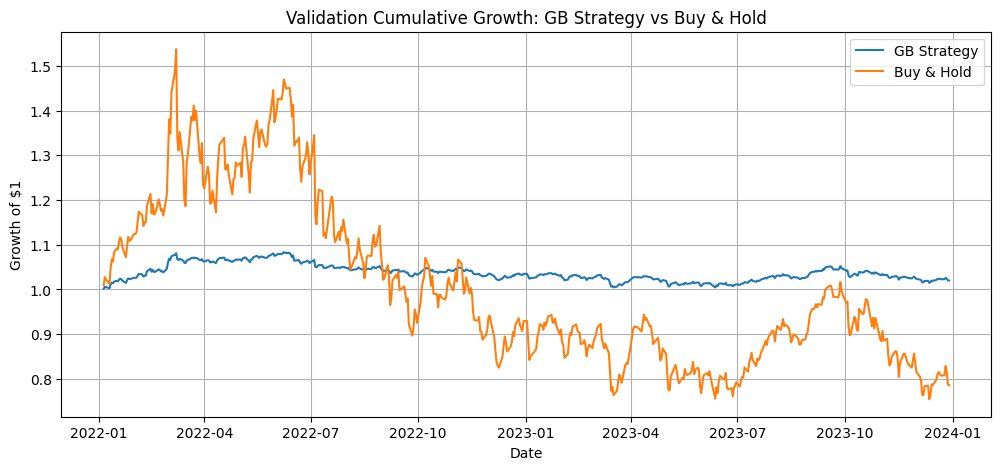

In [282]:
plot_df = gb_val_strategy.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="GB Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: GB Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 12. Probability Calibration Check

To understand whether higher predicted probabilities correspond to stronger realized outcomes, I group validation predictions into probability buckets and compare average predicted probability, realized upward-move frequency, and average return.

In [283]:
val_bucket = gb_val_preds.copy()

val_bucket["bucket"] = pd.cut(val_bucket["prob_up"], bins=10)

bucket_stats = val_bucket.groupby("bucket").agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

print(bucket_stats)

                 returns    Target   prob_up
bucket                                      
(0.489, 0.497]  0.004761  0.666667  0.493825
(0.497, 0.505] -0.000075  0.482759  0.500549
(0.505, 0.513]  0.002994  0.451613  0.506888
(0.513, 0.521] -0.004815  0.513889  0.518713
(0.521, 0.529]  0.001382  0.595506  0.525203
(0.529, 0.537]  0.002656  0.500000  0.535368
(0.537, 0.545]  0.005394  0.560000  0.540644
(0.545, 0.553] -0.007867  0.705882  0.550212
(0.553, 0.561] -0.003380  0.461538  0.557700
(0.561, 0.569] -0.005726  1.000000  0.569069


C:\Users\Nancy Lonoff\AppData\Local\Temp\ipykernel_52640\3832121227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = val_bucket.groupby("bucket").agg({


# Regime-Feature Gradient Boosting Model

This section trains a second gradient boosting model using the HMM regime probabilities as additional predictors. Unlike the baseline model, this version allows the classifier to condition its predictions on the latent market regime estimated from macroeconomic, market-state, and CFTC/COT positioning variables.

## 13. Load HMM-Augmented Modeling Files

The HMM notebook exports train, validation, and test files containing the original predictors plus the regime label and regime probability features. I load those files here and align them with the baseline split dates before training the regime-feature gradient boosting model.

In [284]:
train_base = train_df.copy()
val_base = val_df.copy()
test_base = test_df.copy()

# Load HMM-augmented modeling files.
train_weighted = pd.read_csv("train_final_weighted_hmm.csv")
val_weighted = pd.read_csv("val_final_weighted_hmm.csv")
test_weighted = pd.read_csv("test_final_weighted_hmm.csv")

for df in [train_weighted, val_weighted, test_weighted]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

# Keep only dates that overlap with the original supervised modeling splits.
train_weighted = train_weighted[train_weighted["Date"].isin(train_base["Date"])].copy()
val_weighted = val_weighted[val_weighted["Date"].isin(val_base["Date"])].copy()
test_weighted = test_weighted[test_weighted["Date"].isin(test_base["Date"])].copy()

def align_returns(weighted_df, base_df):
    # Use the return series from the supervised modeling split to ensure consistency.
    weighted_df = weighted_df.drop(columns=["returns"], errors="ignore")

    out = weighted_df.merge(
        base_df[["Date", "returns"]],
        on="Date",
        how="left"
    )

    return out.sort_values("Date").reset_index(drop=True)

train_weighted = align_returns(train_weighted, train_base)
val_weighted = align_returns(val_weighted, val_base)
test_weighted = align_returns(test_weighted, test_base)

print(train_base.shape, train_weighted.shape)
print(val_base.shape, val_weighted.shape)
print(test_base.shape, test_weighted.shape)

(1742, 50) (1742, 51)
(528, 50) (528, 51)
(474, 50) (474, 51)


The HMM-augmented files are renamed into the regime-feature train, validation, and test dataframes. I also drop `macro_month` because it is a date-alignment helper rather than a predictive feature.

In [285]:
train_df_2 = train_weighted
val_df_2 = val_weighted
test_df_2 = test_weighted

train_df_2 = train_df_2.drop(columns=["macro_month"])
val_df_2 = val_df_2.drop(columns=["macro_month"])
test_df_2 = test_df_2.drop(columns=["macro_month"])


for df in [train_df_2, val_df_2, test_df_2]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df_2.shape, val_df_2.shape, test_df_2.shape)
print(train_df_2["Date"].min(), train_df_2["Date"].max())
print(val_df_2["Date"].min(), val_df_2["Date"].max())
print(test_df_2["Date"].min(), test_df_2["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 14. Define Regime-Feature Model Inputs

This feature set includes the HMM regime probabilities but excludes the hard regime label. The probabilities are used because they provide a smoother representation of regime uncertainty, while the hard label is reserved for the later regime-specific model.

In [286]:
target_col = "Target"

regime_feature_exclude_cols = ["Date", "Price", "regime", "returns", "Target"]

feature_cols = [c for c in train_df_2.columns if c not in regime_feature_exclude_cols]

X_train_2 = train_df_2[feature_cols].copy()
y_train_2 = train_df_2[target_col].copy()

X_val_2 = val_df_2[feature_cols].copy()
y_val_2 = val_df_2[target_col].copy()

X_test_2 = test_df_2[feature_cols].copy()
y_test_2 = test_df_2[target_col].copy()

## 14. Define Regime-Feature Model Inputs

This feature set includes the HMM regime probabilities but excludes the hard regime label. The probabilities are used because they provide a smoother representation of regime uncertainty, while the hard label is reserved for the later regime-specific model.

In [ ]:
best_params_2, best_cv_score_2, cv_results_2 = tune_gradient_boosting(
    X_train_2, y_train_2, n_splits=5
)

print("Best params:", best_params_2)
print("Best CV ROC-AUC:", best_cv_score_2)

cv_results_2.head(10)

## 15. Tune the Regime-Feature Gradient Boosting Model

This tuning step repeats the same time-series cross-validation process after adding the HMM regime probability features. The goal is to evaluate whether regime information improves validation performance relative to the baseline feature set.

In [287]:
# these are the best params

gb_baseline_model_2 = GradientBoostingModel(
    learning_rate=0.001,
    max_iter=250,
    max_depth=5,
    min_samples_leaf=40,
    l2_regularization=.10,
    threshold=0.50,
    random_state=42
)

gb_baseline_model_2.fit(X_train_2, y_train_2)

## 17. Generate Regime-Feature Predictions

I generate train, validation, and test predictions for the regime-feature model using the same output format as the baseline model. Keeping the prediction format consistent makes it easier to compare classification and trading performance across model versions.

In [288]:
gb_train_preds_2 = make_prediction_output(train_df_2, X_train_2, y_train_2, gb_baseline_model_2, "gradient_boosting", "regime_feature", "train")
gb_val_preds_2 = make_prediction_output(val_df_2, X_val_2, y_val_2, gb_baseline_model_2, "gradient_boosting", "regime_feature", "val")
gb_test_preds_2 = make_prediction_output(test_df_2, X_test_2, y_test_2, gb_baseline_model_2, "gradient_boosting", "regime_feature", "test")

gb_train_preds_2.to_csv("results/predictions/gb_regime_feature_train_predictions.csv", index=False)
gb_val_preds_2.to_csv("results/predictions/gb_regime_feature_val_predictions.csv", index=False)
gb_test_preds_2.to_csv("results/predictions/gb_regime_feature_test_predictions.csv", index=False)

The summary below checks whether the regime-feature model produces a different probability distribution from the baseline model.

In [289]:
gb_val_preds_2.head()
gb_val_preds_2[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.489207,0.352273,0.530303,-0.000103,0.024159
std,0.031665,0.478131,0.499554,0.025630,0.008671
min,0.458178,0.000000,0.000000,-0.134360,0.008609
25%,0.459274,0.000000,0.000000,-0.015055,0.018637
50%,0.472450,0.000000,1.000000,0.001782,0.022686
75%,0.524706,1.000000,1.000000,0.016680,0.027254
max,0.563387,1.000000,1.000000,0.082612,0.055159


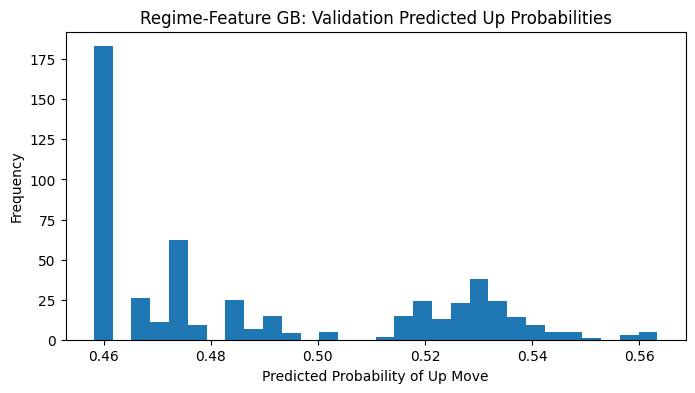

In [290]:
y_val_prob_2 = gb_baseline_model_2.predict_proba(X_val_2)

plt.figure(figsize=(8, 4))
plt.hist(y_val_prob_2, bins=30)
plt.title("Regime-Feature GB: Validation Predicted Up Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Frequency")
plt.show()

The classification metrics below evaluate the regime-feature model on the validation set.

In [292]:
classification_report_simple(gb_val_preds_2)

{'accuracy': 0.5151515151515151,
 'precision': 0.5645161290322581,
 'recall': 0.375,
 'f1': 0.45064377682403434,
 'roc_auc': 0.5379824308755761,
 'confusion_matrix': array([[167,  81],
        [175, 105]], dtype=int64)}

The regime-feature model's validation predictions are converted into trading positions using the same strategy rules as the baseline model.

In [293]:
gb_val_strategy_2 = apply_probability_vol_strategy(gb_val_preds_2)

The table compares validation trading performance for the regime-feature strategy against buy-and-hold.

In [294]:
metrics_2 = pd.DataFrame({
    "GB Strategy Val": strategy_metrics(gb_val_strategy_2, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(gb_val_strategy_2, "buy_hold_return")
}).T

metrics_2

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Strategy Val,0.037235,0.017635,0.039900,0.441982,-0.056243,0.097663,0.097663,0.007518
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000


The plot compares cumulative validation growth for the regime-feature strategy against buy-and-hold.

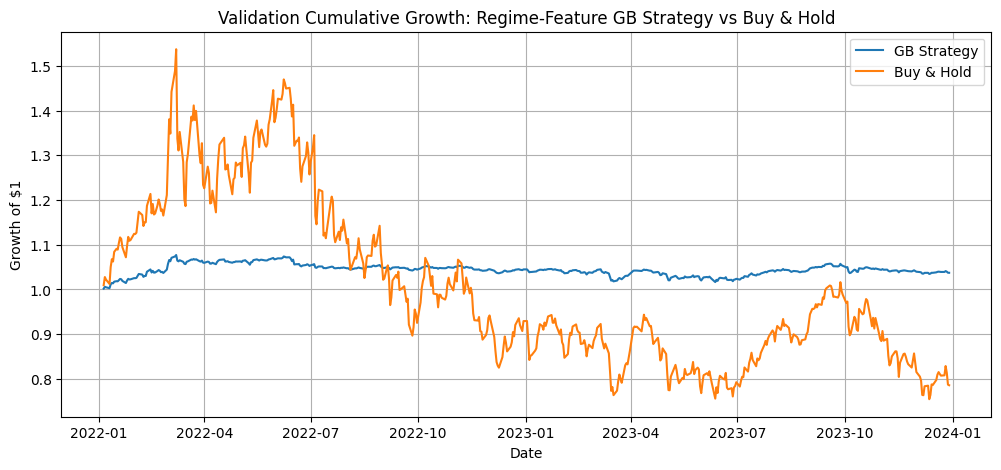

In [ ]:
plot_df_2 = gb_val_strategy_2.dropna(subset=["net_strategy_return"]).copy()

plot_df_2["cum_strategy"] = (1 + plot_df_2["net_strategy_return"]).cumprod()
plot_df_2["cum_buy_hold"] = (1 + plot_df_2["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_2["Date"], plot_df_2["cum_strategy"], label="GB Strategy")
plt.plot(plot_df_2["Date"], plot_df_2["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: Regime-Feature GB Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

This bucket analysis checks whether the regime-feature model's predicted probabilities are directionally meaningful across probability ranges.

In [ ]:
val_bucket_2 = gb_val_preds_2.copy()

val_bucket_2["bucket"] = pd.cut(val_bucket_2["prob_up"], bins=10)

bucket_stats_2 = val_bucket_2.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

print(bucket_stats_2)

                 returns    Target   prob_up
bucket                                      
(0.458, 0.469] -0.001249  0.492823  0.460095
(0.469, 0.479]  0.001026  0.585366  0.472735
(0.479, 0.49]   0.001845  0.468750  0.484993
(0.49, 0.5]     0.004544  0.473684  0.492991
(0.5, 0.511]   -0.002361  0.600000  0.501465
(0.511, 0.521]  0.000894  0.463415  0.518187
(0.521, 0.532]  0.003686  0.540541  0.527678
(0.532, 0.542] -0.006079  0.638298  0.536138
(0.542, 0.553] -0.000137  0.545455  0.545700
(0.553, 0.563] -0.004135  0.875000  0.561029


In [ ]:
comparison_metrics = pd.concat(
    {
        "baseline": metrics,
        "regime_feature": metrics_2
    }
)

comparison_metrics

Total Return      CAGR  Annual Vol    Sharpe  \
baseline       GB Strategy Val      0.019859  0.009447    0.047451  0.199097   
               Buy & Hold Val      -0.205251 -0.103846    0.406865 -0.255235   
regime_feature GB Strategy Val      0.037235  0.017635    0.039900  0.441982   
               Buy & Hold Val      -0.205251 -0.103846    0.406865 -0.255235   

                                Max Drawdown  Avg Position  Avg Abs Position  \
baseline       GB Strategy Val     -0.072640      0.122713          0.122713   
               Buy & Hold Val      -0.509424      1.000000          1.000000   
regime_feature GB Strategy Val     -0.056243      0.097497          0.097497   
               Buy & Hold Val      -0.509424      0.097663          0.097663   

                                Avg Turnover  
baseline       GB Strategy Val      0.007209  
               Buy & Hold Val       0.000000  
regime_feature GB Strategy Val      0.007518  
               Buy & Hold Val       0.007518

The probability summary below compares how the baseline and regime-feature models distribute their predicted upward-move probabilities.

In [ ]:
pd.DataFrame({
    "baseline_val": gb_val_preds["prob_up"].describe(),
    "regime_feature_val": gb_val_preds_2["prob_up"].describe()
})

,baseline_val,regime_feature_val
count,528.000000,528.000000
mean,0.513948,0.489207
std,0.017433,0.031665
min,0.488920,0.458178
25%,0.500691,0.459274
50%,0.505208,0.472450
75%,0.523220,0.524706
max,0.569403,0.563387


# Regime-Specific Gradient Boosting Model

This section trains separate gradient boosting models within each lagged HMM regime. Instead of using one global model for all market environments, the regime-specific approach allows the relationship between predictors and WTI direction to differ across regimes.

The lagged regime label is used instead of the same-day regime label to avoid using regime information that would not have been known at the time the prediction was made.

## 18. Construct Lagged Regime Labels

The regime-specific model uses the previous day's regime label. This prevents look-ahead bias because the prediction for a given date should only use information known before that date's return is realized.

In [300]:
for df in [train_df_2, val_df_2, test_df_2]:
    df["regime_lag"] = df["regime"].shift(1)

## 19. Create Regime-Specific Modeling Copies

I create separate copies of the HMM-augmented train, validation, and test datasets for the regime-specific model. This keeps the regime-specific workflow separate from the earlier regime-feature model.

In [301]:
# Copy the HMM-augmented datasets before constructing lagged regime labels.
train_df_3 = train_df_2.copy()
val_df_3 = val_df_2.copy()
test_df_3 = test_df_2.copy()   

After shifting the regime label by one day, the first observation in each split has no previous regime. I drop only those rows rather than dropping all rows with any missing value.

In [302]:
train_df_3 = train_df_3.dropna(subset=["regime_lag"]).copy()
val_df_3 = val_df_3.dropna(subset=["regime_lag"]).copy()
test_df_3 = test_df_3.dropna(subset=["regime_lag"]).copy()

train_df_3["regime_lag"] = train_df_3["regime_lag"].astype(int)
val_df_3["regime_lag"] = val_df_3["regime_lag"].astype(int)
test_df_3["regime_lag"] = test_df_3["regime_lag"].astype(int)

## 20. Define Regime-Specific Feature Set

For the regime-specific model, the hard regime label and lagged regime label are not used as predictors. They are used only to split the data into separate regime-specific subsets. The HMM regime probabilities are also excluded because the purpose of this version is to train separate models by regime rather than provide regime probabilities to one global model.

In [ ]:
target_col = "Target"

regime_specific_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_lag",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2",
]

feature_cols_3 = [c for c in train_df_3.columns if c not in regime_specific_exclude_cols]

print("Number of regime-specific features:", len(feature_cols_3))
print(feature_cols_3)

Number of regime-specific features: 42
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


## 21. Check Sample Size and Class Balance by Regime

Before fitting separate models, I check how many observations are available in each regime and whether both target classes appear. This matters because regime-specific models can become unstable if one regime has too few observations or if the target is highly imbalanced.

In [ ]:
for r in sorted(train_df_3["regime_lag"].unique()):
    temp = train_df_3[train_df_3["regime_lag"] == r]
    print("Regime:", r)
    print("Rows:", len(temp))
    print(temp["Target"].value_counts())
    print()

Regime: 0
Rows: 662
Target
0    332
1    330
Name: count, dtype: int64

Regime: 1
Rows: 693
Target
1    381
0    312
Name: count, dtype: int64

Regime: 2
Rows: 386
Target
1    221
0    165
Name: count, dtype: int64



## 22. Train One Gradient Boosting Model per Regime

A separate gradient boosting classifier is trained within each lagged regime. If a regime contains only one target class, the notebook stores a fallback probability instead of fitting a classifier, because a classifier cannot learn a two-class decision rule from one class. This uses previously tuned hyperparameters from the regime feature model.

In [ ]:
models_by_regime = {}
fallback_prob_by_regime = {}

for r in sorted(train_df_3["regime_lag"].unique()):
    df_r = train_df_3[train_df_3["regime_lag"] == r].copy()

    X_r = df_r[feature_cols_3]
    y_r = df_r[target_col]

    print(f"Training regime {r}: {len(df_r)} rows")

    # fallback if only one class exists in that regime
    if y_r.nunique() < 2:
        fallback_prob_by_regime[r] = y_r.mean()
        models_by_regime[r] = None
        print(f"Regime {r} has one class only. Using fallback prob:", y_r.mean())
        continue


    model_r = GradientBoostingModel(
        learning_rate=0.001,
        max_iter=250,
        max_depth=5,
        min_samples_leaf=40,
        l2_regularization=.10,
        threshold=0.50,
        random_state=42
    )

    model_r.fit(X_r, y_r)

    models_by_regime[r] = model_r
    fallback_prob_by_regime[r] = y_r.mean()

Training regime 0: 662 rows
Training regime 1: 693 rows
Training regime 2: 386 rows


## 23. Generate Regime-Specific Predictions

This helper function applies the correct model to each observation based on its lagged regime. The output format matches the earlier model versions so that classification and strategy metrics can be compared directly.

In [ ]:
def make_regime_specific_predictions(df, feature_cols, models_by_regime, fallback_prob_by_regime, model_name, version, split_name):
    out = df[["Date", "Price", "returns", "vol_20", "Target", "regime", "regime_lag"]].copy()

    probs = []

    for idx, row in df.iterrows():
        r = int(row["regime_lag"])

        model_r = models_by_regime.get(r)

        if model_r is None:
            prob = fallback_prob_by_regime[r]
        else:
            X_row = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
            prob = model_r.predict_proba(X_row)[0]

        probs.append(prob)

    out["prob_up"] = probs
    out["pred"] = (out["prob_up"] >= 0.50).astype(int)
    out["model"] = model_name
    out["version"] = version
    out["split"] = split_name

    return out

The code below generates train, validation, and test predictions from the regime-specific models.

In [ ]:
gb_train_preds_3 = make_regime_specific_predictions(
    train_df_3,
    feature_cols_3,
    models_by_regime,
    fallback_prob_by_regime,
    "gradient_boosting",
    "regime_specific",
    "train"
)

gb_val_preds_3 = make_regime_specific_predictions(
    val_df_3,
    feature_cols_3,
    models_by_regime,
    fallback_prob_by_regime,
    "gradient_boosting",
    "regime_specific",
    "val"
)

gb_test_preds_3 = make_regime_specific_predictions(
    test_df_3,
    feature_cols_3,
    models_by_regime,
    fallback_prob_by_regime,
    "gradient_boosting",
    "regime_specific",
    "test"
)

The prediction files are saved so they can be reused later for trading-strategy evaluation and result comparison.

In [ ]:
gb_train_preds_3.to_csv("results/predictions/gb_regime_specific_train_predictions.csv", index=False)
gb_val_preds_3.to_csv("results/predictions/gb_regime_specific_val_predictions.csv", index=False)
gb_test_preds_3.to_csv("results/predictions/gb_regime_specific_test_predictions.csv", index=False)

The summary below checks the distribution of predicted probabilities from the regime-specific model.

In [ ]:
gb_val_preds_3["prob_up"].describe()

count    527.000000
mean       0.521322
std        0.030695
min        0.479269
25%        0.496300
50%        0.521775
75%        0.542423
max        0.620747
Name: prob_up, dtype: float64

The validation classification metrics evaluate whether the regime-specific approach improves directional prediction relative to the global models.

In [ ]:
classification_report_simple(gb_val_preds_3)

{'accuracy': 0.5123339658444023,
 'precision': 0.5291005291005291,
 'recall': 0.7168458781362007,
 'f1': 0.60882800608828,
 'roc_auc': 0.5345849231124986,
 'confusion_matrix': array([[ 70, 178],
        [ 79, 200]], dtype=int64)}

The comparison table summarizes validation strategy performance across the baseline, regime-feature, and regime-specific gradient boosting models.

In [ ]:
gb_val_strategy_3 = apply_probability_vol_strategy(gb_val_preds_3)

metrics_3 = pd.DataFrame({
    "GB Regime-Specific Strategy Val": strategy_metrics(gb_val_strategy_3, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(gb_val_strategy_3, "buy_hold_return")
}).T

metrics_3

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Regime-Specific Strategy Val,0.018837,0.008981,0.051754,0.173530,-0.085303,0.137385,0.137385,0.009587
Buy & Hold Val,-0.214415,-0.108988,0.407170,-0.267671,-0.509424,1.000000,1.000000,0.000000


The bucket analysis checks whether higher predicted probabilities are associated with higher realized up rates and returns.

In [ ]:
val_bucket_3 = gb_val_preds_3.copy()

val_bucket_3["bucket"] = pd.cut(val_bucket_3["prob_up"], bins=10)

bucket_stats_3 = val_bucket_3.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

bucket_stats_3

,returns,Target,prob_up
bucket,,,
"(0.479, 0.493]",0.001131,0.511450,0.485380
"(0.493, 0.508]",0.007345,0.525424,0.501357
"(0.508, 0.522]",-0.009447,0.474576,0.509162
"(0.522, 0.536]",-0.001810,0.539130,0.526900
"(0.536, 0.55]",0.000028,0.515464,0.544385
"(0.55, 0.564]",0.003857,0.666667,0.552739
"(0.564, 0.578]",0.005123,0.541667,0.571507
"(0.578, 0.592]",-0.000673,0.588235,0.589473
"(0.592, 0.607]",-0.008546,0.833333,0.604819


In [ ]:
comparison_metrics = pd.concat({
    "baseline": metrics,
    "regime_feature": metrics_2,
    "regime_specific": metrics_3
})

comparison_metrics

Total Return      CAGR  \
baseline        GB Strategy Val                      0.019859  0.009447   
                Buy & Hold Val                      -0.205251 -0.103846   
regime_feature  GB Strategy Val                      0.037235  0.017635   
                Buy & Hold Val                      -0.205251 -0.103846   
regime_specific GB Regime-Specific Strategy Val      0.018837  0.008981   
                Buy & Hold Val                      -0.214415 -0.108988   

                                                 Annual Vol    Sharpe  \
baseline        GB Strategy Val                    0.047451  0.199097   
                Buy & Hold Val                     0.406865 -0.255235   
regime_feature  GB Strategy Val                    0.039900  0.441982   
                Buy & Hold Val                     0.406865 -0.255235   
regime_specific GB Regime-Specific Strategy Val    0.051754  0.173530   
                Buy & Hold Val                     0.407170 -0.267671   

                                                 Max Drawdown  Avg Position  \
baseline        GB Strategy Val                     -0.072640      0.122713   
                Buy & Hold Val                      -0.509424      1.000000   
regime_feature  GB Strategy Val                     -0.056243      0.097663   
                Buy & Hold Val                      -0.509424      1.000000   
regime_specific GB Regime-Specific Strategy Val     -0.085303      0.137385   
                Buy & Hold Val                      -0.509424      1.000000   

                                                 Avg Abs Position  \
baseline        GB Strategy Val                          0.122713   
                Buy & Hold Val                           1.000000   
regime_feature  GB Strategy Val                          0.097663   
                Buy & Hold Val                           1.000000   
regime_specific GB Regime-Specific Strategy Val          0.137385   
                Buy & Hold Val                           1.000000   

                                                 Avg Turnover  
baseline        GB Strategy Val                      0.007209  
                Buy & Hold Val                       0.000000  
regime_feature  GB Strategy Val                      0.007518  
                Buy & Hold Val                       0.000000  
regime_specific GB Regime-Specific Strategy Val      0.009587  
                Buy & Hold Val                       0.000000

The probability summary compares how each model version distributes its predicted upward-move probabilities.

In [ ]:
pd.DataFrame({
    "baseline": gb_val_preds["prob_up"].describe(),
    "regime_feature": gb_val_preds_2["prob_up"].describe(),
    "regime_specific": gb_val_preds_3["prob_up"].describe()
})

,baseline,regime_feature,regime_specific
count,528.000000,528.000000,527.000000
mean,0.513948,0.489207,0.521322
std,0.017433,0.031665,0.030695
min,0.488920,0.458178,0.479269
25%,0.500691,0.459274,0.496300
50%,0.505208,0.472450,0.521775
75%,0.523220,0.524706,0.542423
max,0.569403,0.563387,0.620747


The table below summarizes predicted probabilities by lagged regime, which helps show whether the regime-specific models behave differently across market states.

In [ ]:
gb_val_preds_3.groupby("regime_lag")["prob_up"].describe()

,count,mean,std,min,25%,50%,75%,max
regime_lag,,,,,,,,
0,324.0,0.503040,0.017003,0.479269,0.486969,0.502512,0.521785,0.531207
1,161.0,0.542031,0.017195,0.501488,0.541362,0.543484,0.548489,0.589611
2,42.0,0.582972,0.020907,0.535972,0.575771,0.575771,0.590586,0.620747


The classification report is also computed separately within each lagged regime to diagnose whether performance is concentrated in only one market state.

In [ ]:
for r in sorted(gb_val_preds_3["regime_lag"].unique()):
    temp = gb_val_preds_3[gb_val_preds_3["regime_lag"] == r]

    print(f"\nRegime {r}")
    print("Rows:", len(temp))
    print(classification_report_simple(temp))


Regime 0
Rows: 324
{'accuracy': 0.4845679012345679, 'precision': 0.49714285714285716, 'recall': 0.5240963855421686, 'f1': 0.5102639296187683, 'roc_auc': 0.5112475217324997, 'confusion_matrix': array([[70, 88],
       [79, 87]], dtype=int64)}

Regime 1
Rows: 161
{'accuracy': 0.5403726708074534, 'precision': 0.5403726708074534, 'recall': 1.0, 'f1': 0.7016129032258065, 'roc_auc': 0.5285803044423734, 'confusion_matrix': array([[ 0, 74],
       [ 0, 87]], dtype=int64)}

Regime 2
Rows: 42
{'accuracy': 0.6190476190476191, 'precision': 0.6190476190476191, 'recall': 1.0, 'f1': 0.7647058823529411, 'roc_auc': 0.5841346153846153, 'confusion_matrix': array([[ 0, 16],
       [ 0, 26]], dtype=int64)}


In [ ]:
for r in sorted(gb_val_preds_3["regime_lag"].unique()):
    temp = gb_val_preds_3[gb_val_preds_3["regime_lag"] == r].copy()

    temp["bucket"] = pd.cut(temp["prob_up"], bins=5)

    bucket_stats = temp.groupby("bucket", observed=False).agg({
        "returns": "mean",
        "Target": "mean",
        "prob_up": "mean"
    })

    print(f"\nRegime {r} bucket stats")
    print(bucket_stats)


Regime 0 bucket stats
                 returns    Target   prob_up
bucket                                      
(0.479, 0.49]   0.001131  0.511450  0.485380
(0.49, 0.5]     0.014283  0.571429  0.498040
(0.5, 0.51]    -0.005098  0.493671  0.506919
(0.51, 0.521]  -0.010782  0.428571  0.514119
(0.521, 0.531] -0.002293  0.523256  0.526696

Regime 1 bucket stats
                 returns    Target   prob_up
bucket                                      
(0.501, 0.519]  0.004927  0.454545  0.501488
(0.519, 0.537] -0.000375  0.586207  0.527506
(0.537, 0.554] -0.000656  0.532710  0.545557
(0.554, 0.572]  0.000389  0.571429  0.564438
(0.572, 0.59]  -0.011620  0.571429  0.589611

Regime 2 bucket stats
                 returns    Target   prob_up
bucket                                      
(0.536, 0.553]  0.035589  0.500000  0.539721
(0.553, 0.57]   0.001948  1.000000  0.563826
(0.57, 0.587]   0.008030  0.529412  0.575229
(0.587, 0.604]  0.004234  0.555556  0.590586
(0.604, 0.621] -0.005403  0.800

The regime summary table combines probability behavior, realized target frequency, and average return by lagged regime.

In [ ]:
regime_summary = gb_val_preds_3.groupby("regime_lag").agg(
    rows=("prob_up", "count"),
    mean_prob=("prob_up", "mean"),
    std_prob=("prob_up", "std"),
    min_prob=("prob_up", "min"),
    max_prob=("prob_up", "max"),
    actual_up_rate=("Target", "mean"),
    avg_return=("returns", "mean")
)

regime_summary

,rows,mean_prob,std_prob,min_prob,max_prob,actual_up_rate,avg_return
regime_lag,,,,,,,
0,324,0.503040,0.017003,0.479269,0.531207,0.512346,-0.000702
1,161,0.542031,0.017195,0.501488,0.589611,0.540373,-0.000655
2,42,0.582972,0.020907,0.535972,0.620747,0.619048,0.006353


# Pre-COT Gradient Boosting Baseline

This section trains a gradient boosting model after removing all CFTC/COT positioning variables. The purpose is to create a clean comparison between the original macro/price-based feature set and the COT-augmented models. This helps isolate whether the alternative COT dataset adds useful predictive or trading information.

## 24. Load and Align the Pre-COT Dataset

The pre-COT baseline uses the original train, validation, and test files before adding the COT-enhanced features. I align the dates to the current modeling splits so that comparisons are made on the same sample period. I also align returns to the baseline files so buy-and-hold performance is identical across model versions.

In [ ]:
# Load the original supervised modeling splits.
train_df_pre = pd.read_csv("train_final.csv")
val_df_pre = pd.read_csv("val_final.csv")
test_df_pre = pd.read_csv("test_final.csv")

for df in [train_df_pre, val_df_pre, test_df_pre]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

# align to your current baseline dates
train_df_pre = train_df_pre[train_df_pre["Date"].isin(train_df["Date"])].copy()
val_df_pre = val_df_pre[val_df_pre["Date"].isin(val_df["Date"])].copy()
test_df_pre = test_df_pre[test_df_pre["Date"].isin(test_df["Date"])].copy()

# overwrite returns from baseline to guarantee same buy & hold
def align_returns_to_base(df_new, df_base):
    df_new = df_new.drop(columns=["returns"], errors="ignore")
    out = df_new.merge(
        df_base[["Date", "returns"]],
        on="Date",
        how="left"
    )
    return out.sort_values("Date").reset_index(drop=True)

train_df_pre = align_returns_to_base(train_df_pre, train_df)
val_df_pre = align_returns_to_base(val_df_pre, val_df)
test_df_pre = align_returns_to_base(test_df_pre, test_df)

print(train_df_pre.shape, val_df_pre.shape, test_df_pre.shape)
print(train_df_pre["Date"].min(), train_df_pre["Date"].max())
print(val_df_pre["Date"].min(), val_df_pre["Date"].max())
print(test_df_pre["Date"].min(), test_df_pre["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 25. Identify and Remove COT Features

To construct the pre-COT baseline, I identify columns associated with CFTC/COT positioning data and remove them from the predictor set.

In [ ]:
cot_keywords = [
    "Open_Interest",
    "open_interest",
    "Producer",
    "Merchant",
    "Swap",
    "Money",
    "Other_Reportable",
    "Nonreportable",
    "long",
    "short",
    "Long",
    "Short",
    "net_position",
    "net_position_pct",
    "long_short_ratio",
    "flow",
    "oi_change"
]

cot_cols = [
    c for c in train_df_pre.columns
    if any(keyword in c for keyword in cot_keywords)
]

print("COT columns removed:")
print(cot_cols)
print("Number removed:", len(cot_cols))

COT columns removed:
['net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change']
Number removed: 6


## 26. Define Pre-COT Feature Set

The pre-COT model excludes date fields, prices, realized returns, target labels, regime features, and all COT-related variables. This leaves the macroeconomic and price-derived predictors available before the alternative COT dataset was introduced.

In [ ]:
target_col = "Target"

pre_cot_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
] + cot_cols

feature_cols_pre = [
    c for c in train_df_pre.columns
    if c not in pre_cot_exclude_cols
]

print("Pre-COT feature count:", len(feature_cols_pre))
print(feature_cols_pre)

Pre-COT feature count: 36
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


The predictors and target are split into train, validation, and test matrices for the pre-COT baseline.

In [ ]:
X_train_pre = train_df_pre[feature_cols_pre].copy()
y_train_pre = train_df_pre[target_col].copy()

X_val_pre = val_df_pre[feature_cols_pre].copy()
y_val_pre = val_df_pre[target_col].copy()

X_test_pre = test_df_pre[feature_cols_pre].copy()
y_test_pre = test_df_pre[target_col].copy()

## 27. Tune the Pre-COT Gradient Boosting Model

The pre-COT model is tuned using the same time-series cross-validation procedure as the other gradient boosting models.

In [ ]:
best_params_pre, best_cv_score_pre, cv_results_pre = tune_gradient_boosting(
    X_train_pre,
    y_train_pre,
    n_splits=5
)

print("Best params:", best_params_pre) 
print("Best CV ROC-AUC:", best_cv_score_pre)

cv_results_pre.head(10)

Best params: {'l2_regularization': 0.25, 'learning_rate': 0.01, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 80}
Best CV ROC-AUC: 0.5349847815650589


,learning_rate,max_iter,max_depth,min_samples_leaf,l2_regularization,mean_cv_roc_auc
0,0.01,200,3,80,0.25,0.534985
1,0.01,200,3,80,0.00,0.534449
2,0.01,200,3,80,0.10,0.534243
3,0.01,200,2,80,0.10,0.532822
4,0.01,200,2,40,0.25,0.532795
5,0.01,200,2,80,0.25,0.532601
6,0.01,250,3,80,0.00,0.532574
7,0.01,200,2,40,0.10,0.531883
8,0.01,200,2,40,0.00,0.531744
9,0.01,250,3,80,0.25,0.531566


## 28. Fit the Pre-COT Model

Using the selected hyperparameters, I fit the pre-COT gradient boosting model on the training data.

In [ ]:
gb_pre_cot_model = GradientBoostingModel(
    learning_rate=best_params_pre["learning_rate"],
    max_iter=best_params_pre["max_iter"],
    max_depth=best_params_pre["max_depth"],
    min_samples_leaf=best_params_pre["min_samples_leaf"],
    l2_regularization=best_params_pre["l2_regularization"],
    threshold=0.50,
    random_state=42
)

gb_pre_cot_model.fit(X_train_pre, y_train_pre)

## 29. Generate Pre-COT Predictions

Predictions are generated in the same format as the other model versions so classification and strategy results can be compared directly.

In [ ]:
gb_train_preds_pre = make_prediction_output(
    train_df_pre,
    X_train_pre,
    y_train_pre,
    gb_pre_cot_model,
    "gradient_boosting",
    "pre_cot_baseline",
    "train"
)

gb_val_preds_pre = make_prediction_output(
    val_df_pre,
    X_val_pre,
    y_val_pre,
    gb_pre_cot_model,
    "gradient_boosting",
    "pre_cot_baseline",
    "val"
)

gb_test_preds_pre = make_prediction_output(
    test_df_pre,
    X_test_pre,
    y_test_pre,
    gb_pre_cot_model,
    "gradient_boosting",
    "pre_cot_baseline",
    "test"
)

The pre-COT prediction files are saved for later comparison.

In [ ]:
gb_train_preds_pre.to_csv(
    "results/predictions/gb_pre_cot_baseline_train_predictions.csv",
    index=False
)

gb_val_preds_pre.to_csv(
    "results/predictions/gb_pre_cot_baseline_val_predictions.csv",
    index=False
)

gb_test_preds_pre.to_csv(
    "results/predictions/gb_pre_cot_baseline_test_predictions.csv",
    index=False
)

The summary below checks the distribution of pre-COT validation predictions.

In [ ]:
gb_val_preds_pre[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.487265,0.361742,0.530303,-0.000103,0.024159
std,0.041596,0.480960,0.499554,0.025630,0.008671
min,0.395772,0.000000,0.000000,-0.134360,0.008609
25%,0.466020,0.000000,0.000000,-0.015055,0.018637
50%,0.473661,0.000000,1.000000,0.001782,0.022686
75%,0.507000,1.000000,1.000000,0.016680,0.027254
max,0.636833,1.000000,1.000000,0.082612,0.055159


The validation and test classification reports evaluate the pre-COT model's directional prediction performance.

In [ ]:
classification_report_simple(gb_val_preds_pre)

{'accuracy': 0.509469696969697,
 'precision': 0.5549738219895288,
 'recall': 0.37857142857142856,
 'f1': 0.45010615711252655,
 'roc_auc': 0.5320564516129033,
 'confusion_matrix': array([[163,  85],
        [174, 106]], dtype=int64)}

In [ ]:
classification_report_simple(gb_test_preds_pre)

{'accuracy': 0.5042194092827004,
 'precision': 0.5384615384615384,
 'recall': 0.05907172995780591,
 'f1': 0.10646387832699619,
 'roc_auc': 0.5538642311595364,
 'confusion_matrix': array([[225,  12],
        [223,  14]], dtype=int64)}

The pre-COT validation predictions are converted into trading positions using the same strategy rules as the other model versions.

In [ ]:
gb_val_strategy_pre = apply_probability_vol_strategy(gb_val_preds_pre)

metrics_pre = pd.DataFrame({
    "GB Pre-COT Baseline Strategy Val": strategy_metrics(
        gb_val_strategy_pre,
        "net_strategy_return"
    ),
    "Buy & Hold Val": strategy_metrics(
        gb_val_strategy_pre,
        "buy_hold_return"
    )
}).T

metrics_pre

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Pre-COT Baseline Strategy Val,0.046481,0.021963,0.039221,0.559978,-0.047032,0.090312,0.090732,0.012498
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000


The comparison below places the pre-COT model beside the COT-augmented and regime-enhanced gradient boosting models on validation-period strategy performance.

In [ ]:
gb_baseline_comparison = pd.concat([
    metrics_pre,
    metrics, 
    metrics_2, 
    metrics_3
])

gb_baseline_comparison

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Pre-COT Baseline Strategy Val,0.046481,0.021963,0.039221,0.559978,-0.047032,0.090109,0.090529,0.012498
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,0.090312,0.090732,0.012498
GB Strategy Val,0.019859,0.009447,0.047451,0.199097,-0.072640,0.122605,0.122605,0.007209
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,0.122713,0.122713,0.007209
GB Strategy Val,0.037235,0.017635,0.039900,0.441982,-0.056243,0.097497,0.097497,0.007518
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,0.097663,0.097663,0.007518
GB Regime-Specific Strategy Val,0.018837,0.008981,0.051754,0.173530,-0.085303,0.137054,0.137054,0.009587
Buy & Hold Val,-0.214415,-0.108988,0.407170,-0.267671,-0.509424,0.137385,0.137385,0.009587


The pre-COT bucket analysis checks whether its predicted probabilities are directionally meaningful across probability ranges.

In [ ]:
val_bucket_pre = gb_val_preds_pre.copy()

val_bucket_pre["bucket"] = pd.cut(val_bucket_pre["prob_up"], bins=10)

bucket_stats_pre = val_bucket_pre.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

bucket_stats_pre

,returns,Target,prob_up
bucket,,,
"(0.396, 0.42]",0.004979,0.500000,0.404985
"(0.42, 0.444]",0.003894,0.571429,0.438286
"(0.444, 0.468]",-0.000615,0.483516,0.457240
"(0.468, 0.492]",-0.000168,0.532258,0.474817
"(0.492, 0.516]",0.000197,0.509091,0.504914
"(0.516, 0.54]",0.001985,0.565217,0.524791
"(0.54, 0.565]",-0.000815,0.562500,0.553317
"(0.565, 0.589]",-0.006709,0.633333,0.573460
"(0.589, 0.613]",-0.001892,0.500000,0.596658


# Final Gradient Boosting Test Runs

After comparing model versions on the validation period, I perform final test evaluation. Each final model is retrained on the combined train and validation data, then evaluated once on the held-out test set. This mirrors the realistic workflow where validation is used for model selection and the test set is reserved for final out-of-sample evaluation.

The same final trading-strategy parameters are applied to all final gradient boosting versions so that differences in performance come from the model predictions rather than from model-specific strategy tuning.

## 30. Define Final Tuned Trading Strategy

This function converts final predicted probabilities into trading positions. The final strategy uses the same parameter values across all gradient boosting model versions: a signal multiplier, probability thresholds, asymmetric long/short scaling, nonlinear signal shaping, volatility targeting, position clipping, and transaction costs.

Strategy returns use the previous day's position multiplied by the current day's realized return, which avoids look-ahead bias.

In [304]:
def apply_probability_vol_strategy_tuned(
    preds,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    target_annual_vol=0.28,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    max_position=1.0
):
    df = preds.copy()

    prob = df["prob_up"]

    raw_signal = np.zeros(len(df))

    long_mask = prob >= long_threshold
    short_mask = prob <= short_threshold

    raw_signal[long_mask] = signal_multiplier * (prob[long_mask] - long_threshold)
    raw_signal[short_mask] = signal_multiplier * (prob[short_mask] - short_threshold)

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)
    
    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-max_position, max_position)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = (
        df["gross_strategy_return"] - transaction_cost * df["turnover"]
    )

    df["buy_hold_return"] = df["returns"]

    return df

## 30. Define Final Tuned Trading Strategy

This function converts final predicted probabilities into trading positions. The final strategy uses the same parameter values across all gradient boosting model versions: a signal multiplier, probability thresholds, asymmetric long/short scaling, nonlinear signal shaping, volatility targeting, position clipping, and transaction costs.

Strategy returns use the previous day's position multiplied by the current day's realized return, which avoids look-ahead bias.

In [305]:
trainval_df_pre = pd.concat([train_df_pre, val_df_pre], axis=0).sort_values("Date").reset_index(drop=True)

X_trainval_pre = trainval_df_pre[feature_cols_pre]
y_trainval_pre = trainval_df_pre["Target"]

X_test_pre_final = test_df_pre[feature_cols_pre]
y_test_pre_final = test_df_pre["Target"]


gb_pre_cot_final_model = GradientBoostingModel(
    learning_rate=0.01,
    max_iter=200,
    max_depth=3,
    min_samples_leaf=80,
    l2_regularization=0.25,
    threshold=0.50,
    random_state=42
)

gb_pre_cot_final_model.fit(X_trainval_pre, y_trainval_pre)

gb_test_preds_pre_final = make_prediction_output(
    test_df_pre,
    X_test_pre_final,
    y_test_pre_final,
    gb_pre_cot_final_model,
    "gradient_boosting",
    "pre_cot_baseline_final_trainval",
    "test"
)

gb_test_preds_pre_final.to_csv(
    "results/final_test_predictions/gb_pre_cot_baseline_final_test_predictions.csv",
    index=False
)

gb_test_strategy_pre_final = apply_probability_vol_strategy_tuned(
    gb_test_preds_pre_final,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

gb_pre_final_test_metrics = pd.DataFrame({
    "GB Pre-COT Final Test Strategy": strategy_metrics(
        gb_test_strategy_pre_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gb_test_strategy_pre_final,
        "buy_hold_return"
    )
}).T

gb_pre_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Pre-COT Final Test Strategy,0.015708,0.008338,0.136191,0.061223,-0.144260,0.272953,0.379334,0.122507
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000


The classification report below evaluates the final pre-COT model's directional accuracy on the held-out test set.

In [ ]:
classification_report_simple(gb_test_strategy_pre_final)

{'accuracy': 0.5021097046413502,
 'precision': 0.501466275659824,
 'recall': 0.7215189873417721,
 'f1': 0.5916955017301038,
 'roc_auc': 0.5187024871370329,
 'confusion_matrix': array([[ 67, 170],
        [ 66, 171]], dtype=int64)}

The cumulative-growth plot compares the final pre-COT strategy against buy-and-hold on the test period.

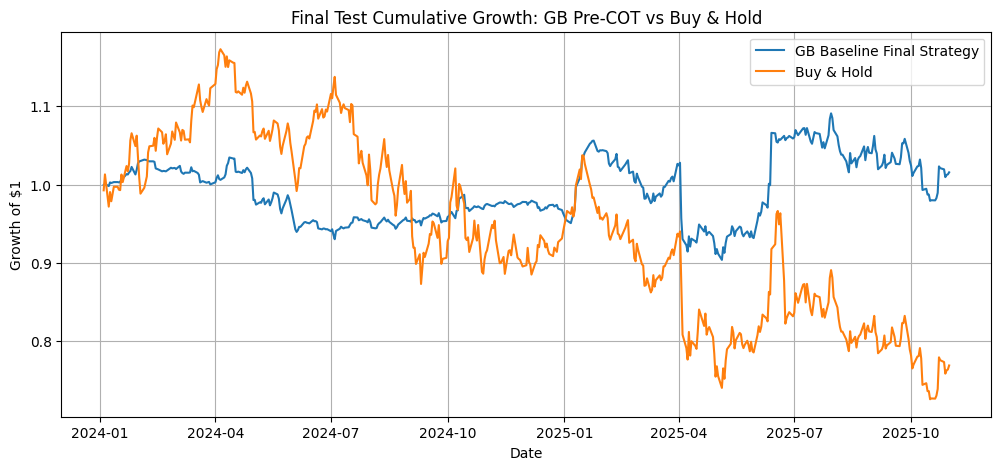

In [ ]:
plot_df = gb_test_strategy_pre_final.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="GB Baseline Final Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: GB Pre-COT vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 32. Final Test Run: COT-Augmented Baseline

This final model uses the COT-augmented feature set but does not include HMM regime features. It is retrained on train plus validation data and evaluated on the held-out test set.

The code below combines the original training and validation periods for the final COT-augmented baseline model.

In [ ]:
trainval_df = pd.concat([train_df, val_df], axis=0).copy()

trainval_df["Date"] = pd.to_datetime(trainval_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

trainval_df = trainval_df.sort_values("Date").reset_index(drop=True)
test_df = test_df.sort_values("Date").reset_index(drop=True)

print("Train+Val:", trainval_df.shape)
print("Test:", test_df.shape)

print(trainval_df["Date"].min(), trainval_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

Train+Val: (2270, 50)
Test: (474, 50)
2015-05-24 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


In [ ]:
trainval_df = pd.concat([train_df, val_df], axis=0).sort_values("Date").reset_index(drop=True)

X_trainval = trainval_df[feature_cols]
y_trainval = trainval_df["Target"]

X_test_final = test_df[feature_cols]
y_test_final = test_df["Target"]

print(X_trainval.shape, X_test_final.shape)

(2270, 42) (474, 42)


The final COT-augmented baseline model is fit on train plus validation data, used to generate test predictions, and then evaluated using the common final trading rule.

In [ ]:
gb_final_model = GradientBoostingModel(
    learning_rate=0.001,
    max_iter=250,
    max_depth=5,
    min_samples_leaf=80,
    l2_regularization=0.25,
    threshold=0.50,
    random_state=42
)

gb_final_model.fit(X_trainval, y_trainval)

gb_test_preds_final = make_prediction_output(
    test_df,
    X_test_final,
    y_test_final,
    gb_final_model,
    "gradient_boosting",
    "baseline_final_trainval",
    "test"
)

gb_test_preds_final.head()


gb_test_preds_final.to_csv(
    "results/final_test_predictions/gb_baseline_final_test_predictions.csv",
    index=False
)

gb_test_strategy_final = apply_probability_vol_strategy_tuned(
    gb_test_preds_final,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

gb_final_test_metrics = pd.DataFrame({
    "GB Baseline Final Test Strategy": strategy_metrics(
        gb_test_strategy_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gb_test_strategy_final,
        "buy_hold_return"
    )
}).T

gb_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Baseline Final Test Strategy,-0.081531,-0.044299,0.164820,-0.268774,-0.228220,0.534756,0.534756,0.036749
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000


The classification report evaluates the final COT-augmented baseline model on the held-out test set.

In [ ]:
classification_report_simple(gb_test_strategy_final)

{'accuracy': 0.5,
 'precision': 0.5,
 'recall': 1.0,
 'f1': 0.6666666666666666,
 'roc_auc': 0.5097829763748687,
 'confusion_matrix': array([[  0, 237],
        [  0, 237]], dtype=int64)}

The classification report evaluates the final COT-augmented baseline model on the held-out test set.

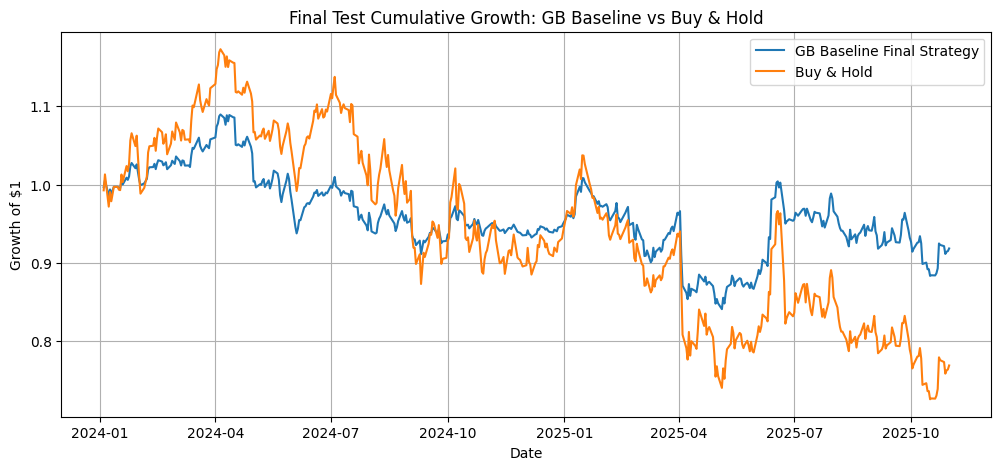

In [ ]:
plot_df = gb_test_strategy_final.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="GB Baseline Final Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: GB Baseline vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 33. Final Test Run: Regime-Feature Model

The regime-feature model uses the HMM regime probabilities as additional predictors in one global gradient boosting classifier. It is retrained on train plus validation data and evaluated on the held-out test set.

The final regime-feature model is trained on the combined train and validation data using the HMM regime probabilities as predictors.

In [ ]:
trainval_df_2 = pd.concat([train_df_2, val_df_2], axis=0).sort_values("Date").reset_index(drop=True)

# if rerunning this code be cautious because feature_cols may have been overwritten
X_trainval_2 = trainval_df_2[feature_cols]
y_trainval_2 = trainval_df_2["Target"]

X_test_2_final = test_df_2[feature_cols]
y_test_2_final = test_df_2["Target"]

gb_baseline_model_2 = GradientBoostingModel(
    learning_rate=0.001,
    max_iter=250,
    max_depth=5,
    min_samples_leaf=40,
    l2_regularization=.10,
    threshold=0.50,
    random_state=42
)

gb_baseline_model_2.fit(X_trainval_2, y_trainval_2)

gb_test_preds_final_2 = make_prediction_output(
    test_df_2,
    X_test_2_final,
    y_test_2_final,
    gb_baseline_model_2,
    "gradient_boosting",
    "baseline_final_trainval",
    "test"
)

gb_test_preds_final_2.head()

gb_test_preds_final_2.to_csv(
    "results/final_test_predictions/gb_regime_feature_final_test_predictions.csv",
    index=False
)

The classification report evaluates the final regime-feature model on the held-out test set.

In [ ]:
classification_report_simple(gb_test_preds_final_2)

{'accuracy': 0.5210970464135021,
 'precision': 0.5109649122807017,
 'recall': 0.9831223628691983,
 'f1': 0.6724386724386724,
 'roc_auc': 0.5196816749452545,
 'confusion_matrix': array([[ 14, 223],
        [  4, 233]], dtype=int64)}

The final regime-feature predictions are converted into trading positions using the common final trading rule.

In [ ]:
gb_test_strategy_final_2 = apply_probability_vol_strategy_tuned(
    gb_test_preds_final_2,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

gb_2_final_test_metrics = pd.DataFrame({
    "GB Regime-Feature Final Test Strategy": strategy_metrics(
        gb_test_strategy_final_2,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gb_test_strategy_final_2,
        "buy_hold_return"
    )
}).T

gb_2_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Regime-Feature Final Test Strategy,-0.044403,-0.023907,0.181059,-0.132041,-0.191299,0.527506,0.534041,0.057084
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000


The final regime-feature predictions are converted into trading positions using the common final trading rule.

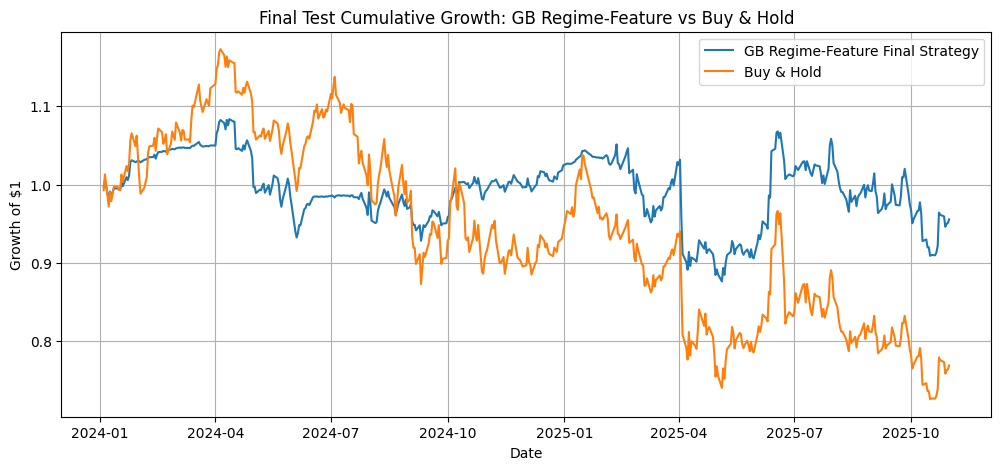

In [ ]:
plot_df_2 = gb_test_strategy_final_2.dropna(subset=["net_strategy_return"]).copy()

plot_df_2["cum_strategy"] = (1 + plot_df_2["net_strategy_return"]).cumprod()
plot_df_2["cum_buy_hold"] = (1 + plot_df_2["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_2["Date"], plot_df_2["cum_strategy"], label="GB Regime-Feature Final Strategy")
plt.plot(plot_df_2["Date"], plot_df_2["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: GB Regime-Feature vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 34. Final Test Run: Regime-Specific Model

The regime-specific model trains separate gradient boosting classifiers within each lagged HMM regime using the combined train and validation data. Final test predictions are generated by applying the model corresponding to each observation's lagged regime.

The code below prepares the combined train-validation dataset for final regime-specific model fitting and verifies the number of observations in each lagged regime.

In [ ]:
trainval_df_3 = pd.concat([train_df_3, val_df_3], axis=0).copy()
trainval_df_3["Date"] = pd.to_datetime(trainval_df_3["Date"])
test_df_3["Date"] = pd.to_datetime(test_df_3["Date"])

trainval_df_3 = trainval_df_3.sort_values("Date").reset_index(drop=True)
test_df_3 = test_df_3.sort_values("Date").reset_index(drop=True)

print("Regime-specific train+val:", trainval_df_3.shape)
print("Regime-specific test:", test_df_3.shape)

print("\nTrain+Val regimes:")
print(trainval_df_3["regime_lag"].value_counts())

print("\nTest regimes:")
print(test_df_3["regime_lag"].value_counts())

print("\nFeature count:", len(feature_cols_3))
print("Regime probability columns included:")
print([c for c in feature_cols_3 if "regime_prob" in c])

Regime-specific train+val: (2268, 51)
Regime-specific test: (473, 51)

Train+Val regimes:
regime_lag
0    986
1    854
2    428
Name: count, dtype: int64

Test regimes:
regime_lag
0    349
1    124
Name: count, dtype: int64

Feature count: 42
Regime probability columns included:
[]


Each final regime-specific model is trained only on observations from the corresponding lagged regime. A fallback probability is stored in case a regime does not contain both target classes.

In [ ]:
gb_regime_models_final = {}

for regime in sorted(trainval_df_3["regime_lag"].unique()):
    print(f"\nTraining final GB model for regime {regime}")

    trainval_r = trainval_df_3[trainval_df_3["regime_lag"] == regime].copy()

    X_trainval_r = trainval_r[feature_cols_3].copy()
    y_trainval_r = trainval_r["Target"].copy()

    print("Rows:", len(trainval_r))
    print("X shape:", X_trainval_r.shape)

    model_r = GradientBoostingModel(
        learning_rate=0.001,
        max_iter=250,
        max_depth=5,
        min_samples_leaf=40,
        l2_regularization=0.10,
        threshold=0.50,
        random_state=42
    )

    model_r.fit(X_trainval_r, y_trainval_r)

    gb_regime_models_final[regime] = model_r


Training final GB model for regime 0
Rows: 986
X shape: (986, 42)

Training final GB model for regime 1
Rows: 854
X shape: (854, 42)

Training final GB model for regime 2
Rows: 428
X shape: (428, 42)


Each final regime-specific model is trained only on observations from the corresponding lagged regime. A fallback probability is stored in case a regime does not contain both target classes.

In [ ]:
def make_regime_specific_gb_predictions_final(
    df,
    feature_cols,
    regime_models,
    model_name="gradient_boosting",
    version="regime_specific_final_trainval",
    split_name="test"
):
    pred_list = []

    for regime, model in regime_models.items():
        df_r = df[df["regime_lag"] == regime].copy()

        if len(df_r) == 0:
            print(f"No rows for regime {regime}")
            continue

        X_r = df_r[feature_cols].copy()
        y_r = df_r["Target"].copy()

        preds_r = make_prediction_output(
            df_r,
            X_r,
            y_r,
            model,
            model_name,
            version,
            split_name
        )

        preds_r["regime_lag"] = regime
        pred_list.append(preds_r)

    out = pd.concat(pred_list, ignore_index=True)
    out = out.sort_values("Date").reset_index(drop=True)

    return out

gb_test_preds_3_final = make_regime_specific_gb_predictions_final(
    test_df_3,
    feature_cols_3,
    gb_regime_models_final,
    model_name="gradient_boosting",
    version="regime_specific_final_trainval",
    split_name="test"
)

gb_test_preds_3_final.head()

No rows for regime 2


,Date,Price,returns,vol_20,Target,prob_up,pred,model,version,split,regime_lag
0,2024-01-04,72.36,-0.007298,0.019480,1,0.507895,1,gradient_boosting,regime_specific_final_trainval,test,0
1,2024-01-05,73.86,0.020518,0.019134,0,0.504336,1,gradient_boosting,regime_specific_final_trainval,test,0
2,2024-01-08,70.92,-0.040619,0.021280,1,0.504336,1,gradient_boosting,regime_specific_final_trainval,test,0
3,2024-01-09,72.29,0.019133,0.019744,0,0.504336,1,gradient_boosting,regime_specific_final_trainval,test,0
4,2024-01-10,71.44,-0.011828,0.019846,1,0.504336,1,gradient_boosting,regime_specific_final_trainval,test,0


The final regime-specific test predictions are saved for reporting and strategy evaluation.

In [ ]:
gb_test_preds_3_final.to_csv(
    "results/final_test_predictions/gb_regime_specific_final_test_predictions.csv",
    index=False
)

The classification report evaluates the final regime-specific model on the held-out test set.

In [ ]:
classification_report_simple(gb_test_preds_3_final)

{'accuracy': 0.5391120507399577,
 'precision': 0.5307443365695793,
 'recall': 0.6919831223628692,
 'f1': 0.6007326007326007,
 'roc_auc': 0.5200958306515054,
 'confusion_matrix': array([[ 91, 145],
        [ 73, 164]], dtype=int64)}

The final regime-specific predictions are converted into trading positions using the same final trading rule as the other model versions.

In [ ]:
gb_test_strategy_3_final = apply_probability_vol_strategy_tuned(
    gb_test_preds_3_final,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

gb_3_final_test_metrics = pd.DataFrame({
    "GB Regime-Specific Final Test Strategy": strategy_metrics(
        gb_test_strategy_3_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gb_test_strategy_3_final,
        "buy_hold_return"
    )
}).T

gb_3_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GB Regime-Specific Final Test Strategy,0.071266,0.037438,0.096678,0.387246,-0.097971,0.202464,0.288943,0.07257
Buy & Hold Final Test,-0.230993,-0.130585,0.298687,-0.437197,-0.381141,1.000000,1.000000,0.00000


The cumulative-growth plot compares the final regime-specific strategy against buy-and-hold.

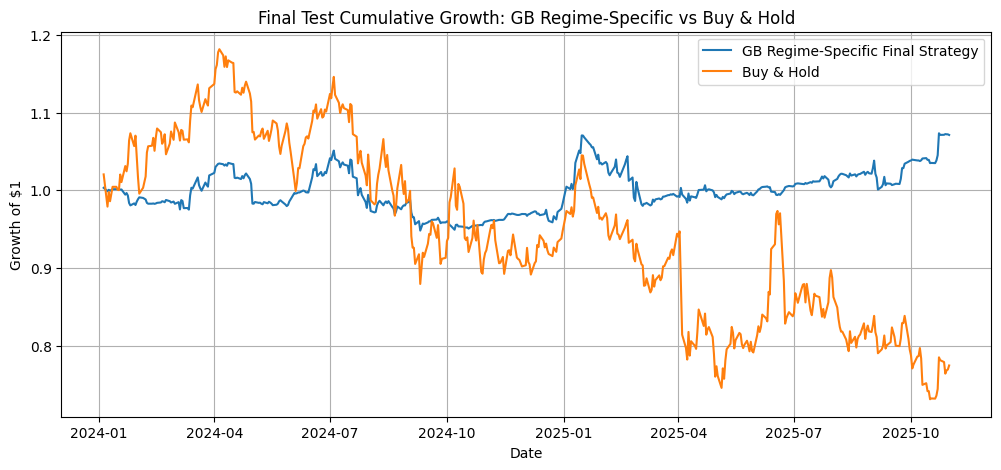

In [ ]:
plot_df_3 = gb_test_strategy_3_final.dropna(subset=["net_strategy_return"]).copy()

plot_df_3["cum_strategy"] = (1 + plot_df_3["net_strategy_return"]).cumprod()
plot_df_3["cum_buy_hold"] = (1 + plot_df_3["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_3["Date"], plot_df_3["cum_strategy"], label="GB Regime-Specific Final Strategy")
plt.plot(plot_df_3["Date"], plot_df_3["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: GB Regime-Specific vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 35. Final Gradient Boosting Comparison

The table below combines final test-period strategy metrics for all gradient boosting versions: pre-COT, COT-augmented baseline, regime-feature, regime-specific, and buy-and-hold.

In [ ]:
final_comparison = pd.concat({
    "pre_cot": gb_pre_final_test_metrics,
    "baseline": gb_final_test_metrics,
    "regime_feature": gb_2_final_test_metrics,
    "regime_specific": gb_3_final_test_metrics
})

final_comparison

Total Return  \
pre_cot         GB Pre-COT Final Test Strategy              0.015708   
                Buy & Hold Final Test                      -0.206663   
baseline        GB Baseline Final Test Strategy            -0.081531   
                Buy & Hold Final Test                      -0.206663   
regime_feature  GB Regime-Feature Final Test Strategy      -0.044403   
                Buy & Hold Final Test                      -0.206663   
regime_specific GB Regime-Specific Final Test Strategy      0.071266   
                Buy & Hold Final Test                      -0.230993   

                                                            CAGR  Annual Vol  \
pre_cot         GB Pre-COT Final Test Strategy          0.008338    0.136191   
                Buy & Hold Final Test                  -0.115807    0.299283   
baseline        GB Baseline Final Test Strategy        -0.044299    0.164820   
                Buy & Hold Final Test                  -0.115807    0.299283   
regime_feature  GB Regime-Feature Final Test Strategy  -0.023907    0.181059   
                Buy & Hold Final Test                  -0.115807    0.299283   
regime_specific GB Regime-Specific Final Test Strategy  0.037438    0.096678   
                Buy & Hold Final Test                  -0.130585    0.298687   

                                                          Sharpe  \
pre_cot         GB Pre-COT Final Test Strategy          0.061223   
                Buy & Hold Final Test                  -0.386948   
baseline        GB Baseline Final Test Strategy        -0.268774   
                Buy & Hold Final Test                  -0.386948   
regime_feature  GB Regime-Feature Final Test Strategy  -0.132041   
                Buy & Hold Final Test                  -0.386948   
regime_specific GB Regime-Specific Final Test Strategy  0.387246   
                Buy & Hold Final Test                  -0.437197   

                                                        Max Drawdown  \
pre_cot         GB Pre-COT Final Test Strategy             -0.144260   
                Buy & Hold Final Test                      -0.381141   
baseline        GB Baseline Final Test Strategy            -0.228220   
                Buy & Hold Final Test                      -0.381141   
regime_feature  GB Regime-Feature Final Test Strategy      -0.191299   
                Buy & Hold Final Test                      -0.381141   
regime_specific GB Regime-Specific Final Test Strategy     -0.097971   
                Buy & Hold Final Test                      -0.381141   

                                                        Avg Position  \
pre_cot         GB Pre-COT Final Test Strategy              0.272953   
                Buy & Hold Final Test                       1.000000   
baseline        GB Baseline Final Test Strategy             0.534756   
                Buy & Hold Final Test                       1.000000   
regime_feature  GB Regime-Feature Final Test Strategy       0.527506   
                Buy & Hold Final Test                       1.000000   
regime_specific GB Regime-Specific Final Test Strategy      0.202464   
                Buy & Hold Final Test                       1.000000   

                                                        Avg Abs Position  \
pre_cot         GB Pre-COT Final Test Strategy                  0.379334   
                Buy & Hold Final Test                           1.000000   
baseline        GB Baseline Final Test Strategy                 0.534756   
                Buy & Hold Final Test                           1.000000   
regime_feature  GB Regime-Feature Final Test Strategy           0.534041   
                Buy & Hold Final Test                           1.000000   
regime_specific GB Regime-Specific Final Test Strategy          0.288943   
                Buy & Hold Final Test                           1.000000   

                                                        Avg Turnover  
pre_cot         GB 

The bar charts compare final test performance across the main strategy metrics: total return, Sharpe ratio, maximum drawdown, and annualized volatility.

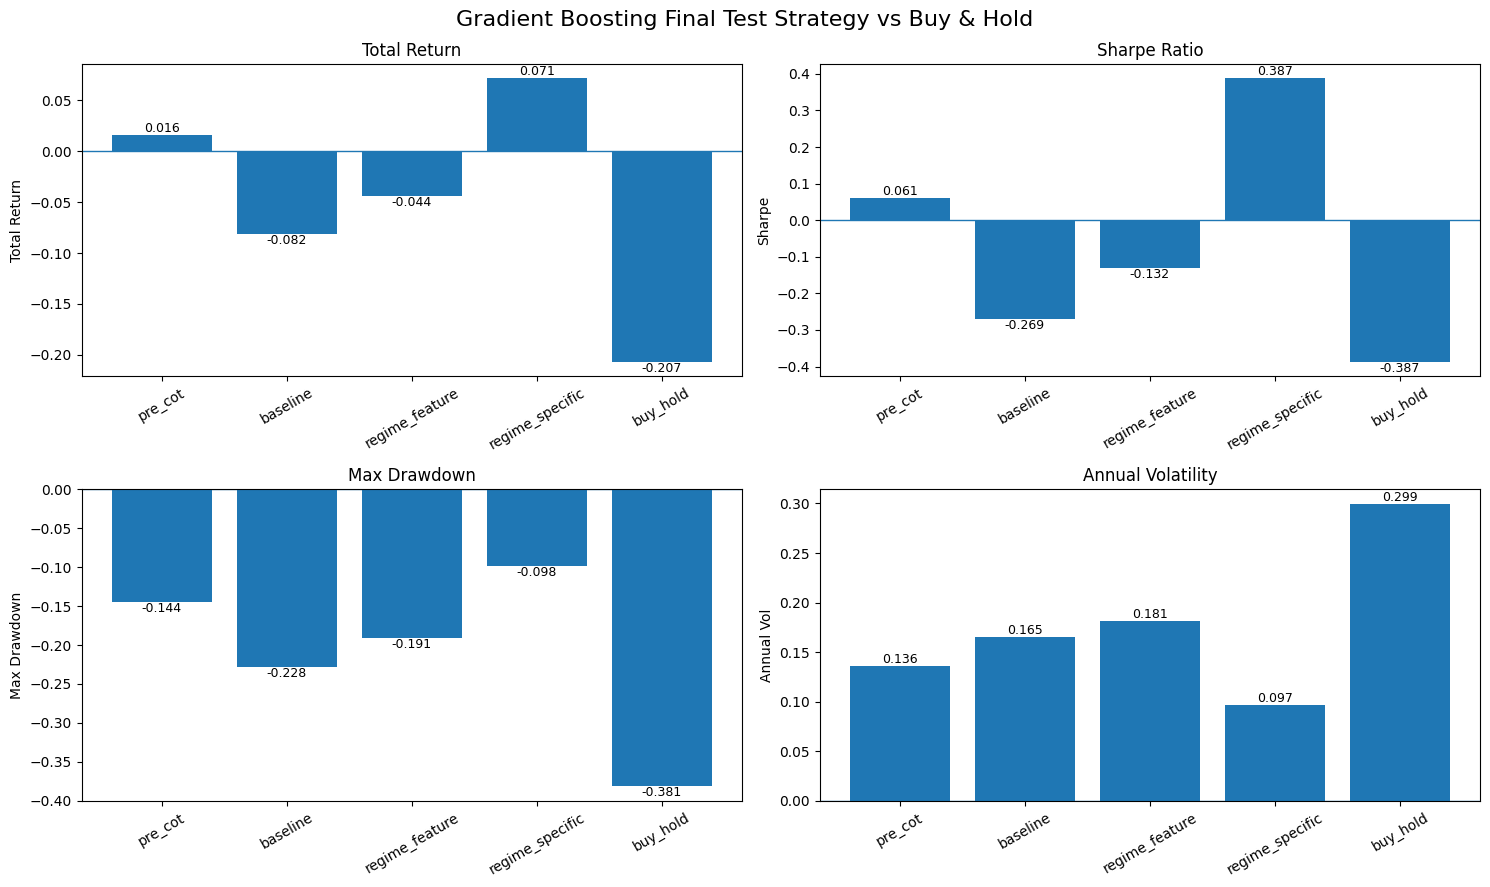

In [ ]:
# Keep strategy rows
strategy_metrics = final_comparison[
    ~final_comparison.index.get_level_values(1).str.contains("Buy & Hold")
].copy()

strategy_metrics.index = strategy_metrics.index.get_level_values(0)

# Add one Buy & Hold row
buy_hold_metrics = final_comparison[
    final_comparison.index.get_level_values(1).str.contains("Buy & Hold")
].iloc[0].copy()

strategy_metrics.loc["buy_hold"] = buy_hold_metrics

# Optional: order rows
strategy_metrics = strategy_metrics.loc[
    ["pre_cot", "baseline", "regime_feature", "regime_specific", "buy_hold"]
]

metrics_to_plot = {
    "Total Return": "Total Return",
    "Sharpe": "Sharpe Ratio",
    "Max Drawdown": "Max Drawdown",
    "Annual Vol": "Annual Volatility"
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_to_plot.items()):
    values = strategy_metrics[metric]
    bars = ax.bar(values.index, values.values)

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.axhline(0, linewidth=1)
    ax.tick_params(axis="x", rotation=30)

    for bar in bars:
        height = bar.get_height()
        va = "bottom" if height >= 0 else "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va=va,
            fontsize=9
        )

plt.suptitle("Gradient Boosting Final Test Strategy vs Buy & Hold", fontsize=16)
plt.tight_layout()
plt.show()